# RQ1 report plots

Nick Grebe i6377605

RQ1: Does the spatio-temporal transformer improve pedestrian trajectory prediction accuracy compared to the LSTM baseline, measured by ADE and FDE over short-term horizons, while satisfying the runtime budget?


In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math

import numpy as np
import pandas as pd
from IPython.display import display

from Reporting.reporting_notebook_utils import (
    METRIC_LABEL_ORDER,
    MODEL_COLORS,
    MODEL_ORDER,
    budget_line_from_summary,
    configure_notebook,
    derive_rq1_columns,
    diverging_norm,
    load_rq1_outputs,
    require_columns,
    results_to_long,
    save_figure,
    sem,
    sorted_unique,
    split_sort_key,
)

base_dir, figures_dir, plt = configure_notebook("rq1", font_size=10, display_width=180)

Base directory: /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq1
Figures directory: /Users/nickgrebe/Desktop/DSAI_YEAR2/project_2-2_25-26_dsai_group-12/Reporting/rq1/figures


## Load and prepare RQ1 outputs

In [10]:
df, summary_df = load_rq1_outputs(base_dir)
rq1_df, split_level_df, pooled_df = derive_rq1_columns(df)

horizon_order = (
    rq1_df[["horizon_for_plot", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_for_plot")
    .reset_index(drop=True)
)
horizon_values = horizon_order["horizon_for_plot"].tolist()
horizon_labels = horizon_order["horizon_label"].tolist()
split_order = sorted_unique(split_level_df["split"])
metric_order = [metric for metric in METRIC_LABEL_ORDER if metric in set(rq1_df["metric_label"])]
metric_order.extend([metric for metric in sorted_unique(rq1_df["metric_label"]) if metric not in metric_order])

print("Metric labels:", metric_order)
print("Horizon labels:", horizon_labels)
print("Using pooled rows for main error comparison:", not pooled_df.empty)
display_columns = [
    "split", "metric_label", "horizon_label", "n_pairs", "mean_lstm_error", "mean_stt_error",
    "improvement_pct", "p_value", "holm_p_value", "significant_raw", "significant_adjusted",
    "baseline_budget_pass", "treatment_budget_pass",
]
display(rq1_df.sort_values(["is_pooled", "split", "metric_label", "horizon_for_plot"])[[c for c in display_columns if c in rq1_df]])


Loaded 5 RQ1 split folder(s): ['MOT20-01', 'MOT20-02', 'MOT20-03', 'MOT20-05', 'MOT20-POOLED']
Combined RQ1 result shape: (30, 39)
Metric labels: ['ADE', 'FDE']
Horizon labels: ['0.6s', '1.0s', '2.0s']
Using pooled rows for main error comparison: True


,split,metric_label,horizon_label,n_pairs,mean_lstm_error,mean_stt_error,improvement_pct,p_value,holm_p_value,significant_raw,significant_adjusted,baseline_budget_pass,treatment_budget_pass
0,MOT20-01,ADE,0.6s,86,0.010856,0.008537,21.356323,0.0001,0.0006,True,True,True,True
2,MOT20-01,ADE,1.0s,86,0.016497,0.012775,22.563202,0.0001,0.0006,True,True,True,True
4,MOT20-01,ADE,2.0s,86,0.030242,0.023114,23.570929,0.0001,0.0006,True,True,True,True
1,MOT20-01,FDE,0.6s,86,0.016471,0.012704,22.869828,0.0001,0.0006,True,True,True,True
3,MOT20-01,FDE,1.0s,86,0.027765,0.021359,23.069216,0.0001,0.0006,True,True,True,True
5,MOT20-01,FDE,2.0s,86,0.054569,0.041509,23.932149,0.0001,0.0006,True,True,True,True
6,MOT20-02,ADE,0.6s,291,0.014366,0.008213,42.829728,0.0001,0.0006,True,True,False,True
8,MOT20-02,ADE,1.0s,291,0.021072,0.012210,42.055674,0.0001,0.0006,True,True,False,True
10,MOT20-02,ADE,2.0s,291,0.037798,0.022665,40.036356,0.0001,0.0006,True,True,False,True
7,MOT20-02,FDE,0.6s,291,0.021117,0.012407,41.243249,0.0001,0.0006,True,True,False,True


## Main RQ1 error comparison by horizon

Uses pooled RQ1 rows when available. Error bars show split-level standard error across held-out MOT20 sequences.


Saved figures/rq1_error_by_horizon.png


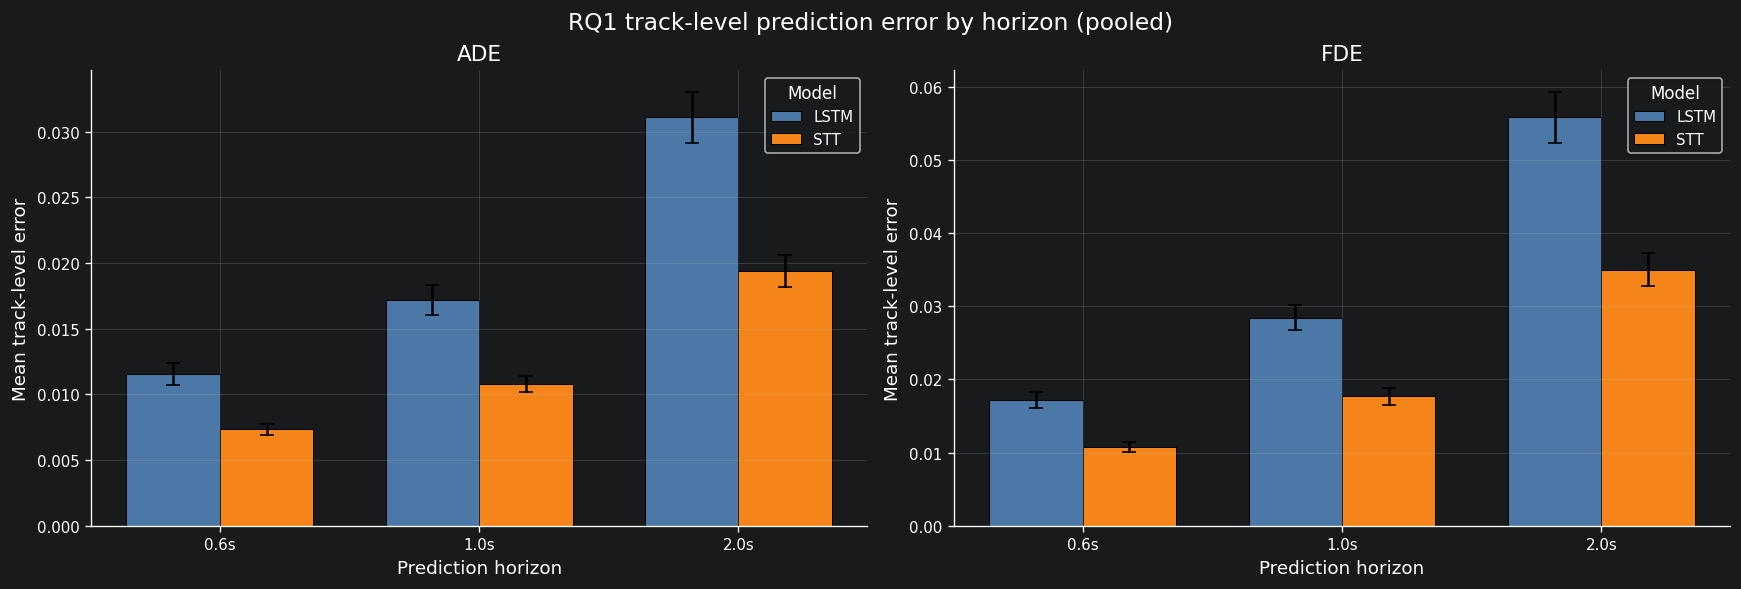

In [11]:
central_df = pooled_df if not pooled_df.empty else split_level_df
central_source = "pooled" if not pooled_df.empty else "split mean"
central_long = results_to_long(central_df)
if pooled_df.empty:
    central_long = central_long.groupby(
        ["metric_label", "horizon_for_plot", "horizon_label", "model_label"], as_index=False
    ).agg(mean_error=("mean_error", "mean"))

error_summary = results_to_long(split_level_df).groupby(
    ["metric_label", "horizon_label", "model_label"], as_index=False
).agg(error_sem=("mean_error", sem))

fig, axes = plt.subplots(1, len(metric_order), figsize=(7.2 * len(metric_order), 4.8), constrained_layout=True)
axes = [axes] if len(metric_order) == 1 else axes
x = np.arange(len(horizon_labels))
width = 0.36

for ax, metric_label in zip(axes, metric_order):
    metric_data = central_long[central_long["metric_label"] == metric_label]
    for model_idx, model_label in enumerate(MODEL_ORDER):
        model_data = metric_data[metric_data["model_label"] == model_label].set_index("horizon_label").reindex(horizon_labels)
        err = error_summary[
            (error_summary["metric_label"] == metric_label) & (error_summary["model_label"] == model_label)
        ].set_index("horizon_label").reindex(horizon_labels)["error_sem"].to_numpy(dtype=float)
        ax.bar(
            x + (model_idx - 0.5) * width,
            model_data["mean_error"].to_numpy(dtype=float),
            width=width,
            yerr=None if np.all(np.isnan(err)) else err,
            capsize=4,
            label=model_label,
            color=MODEL_COLORS[model_label],
            edgecolor="black",
            linewidth=0.6,
        )
    ax.set(title=metric_label, xlabel="Prediction horizon", ylabel="Mean track-level error")
    ax.set_xticks(x, horizon_labels)
    ax.legend(title="Model")

fig.suptitle(f"RQ1 track-level prediction error by horizon ({central_source})", fontsize=14)
save_figure(fig, figures_dir, base_dir, "rq1_error_by_horizon")
plt.show()


## Relative improvement by split and horizon

Positive values mean STT has lower track-level prediction error than LSTM on the same matched evaluation units.


Saved figures/rq1_relative_improvement_by_split.png


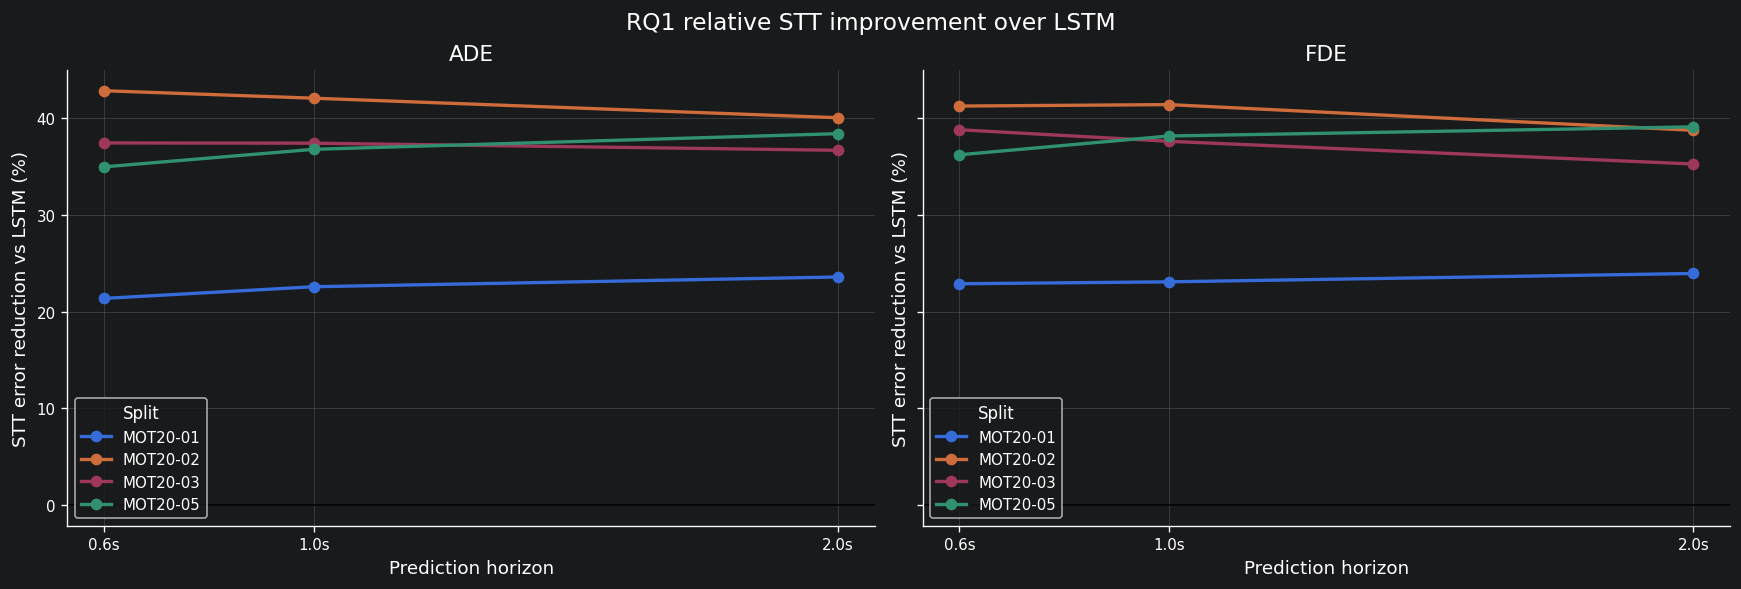

In [12]:
fig, axes = plt.subplots(1, len(metric_order), figsize=(7.2 * len(metric_order), 4.8), sharey=True, constrained_layout=True)
axes = [axes] if len(metric_order) == 1 else axes

for ax, metric_label in zip(axes, metric_order):
    metric_data = split_level_df[split_level_df["metric_label"] == metric_label]
    for split in split_order:
        line_data = metric_data[metric_data["split"] == split].sort_values("horizon_for_plot")
        if not line_data.empty:
            ax.plot(line_data["horizon_for_plot"], line_data["improvement_pct"], marker="o", linewidth=2, label=split)
    ax.axhline(0, color="black", linewidth=1)
    ax.set(title=metric_label, xlabel="Prediction horizon", ylabel="STT error reduction vs LSTM (%)")
    ax.set_xticks(horizon_values, horizon_labels)
    ax.legend(title="Split")

fig.suptitle("RQ1 relative STT improvement over LSTM", fontsize=14)
save_figure(fig, figures_dir, base_dir, "rq1_relative_improvement_by_split")
plt.show()


## Heatmap of relative improvement

Saved figures/rq1_relative_improvement_heatmap.png


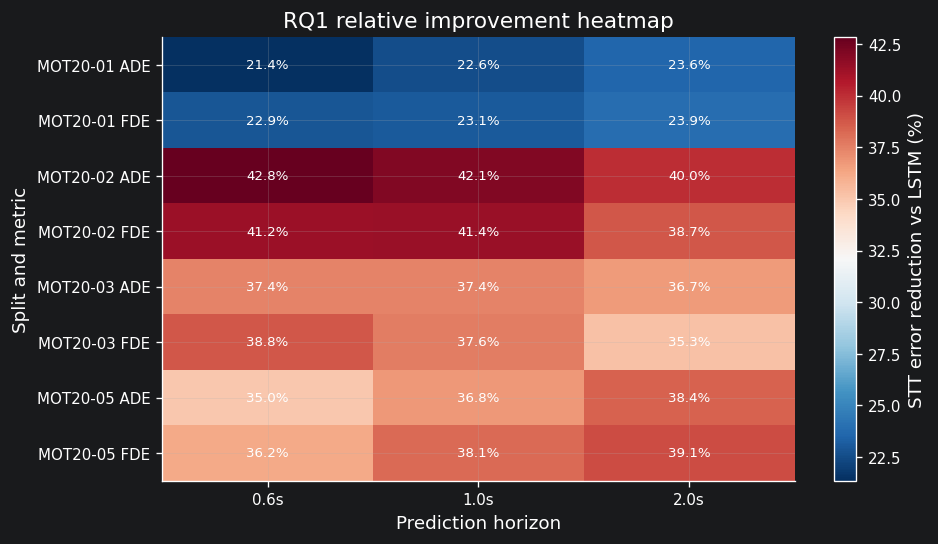

In [13]:
heatmap_df = split_level_df.copy()
heatmap_df["row_label"] = heatmap_df["split"] + " " + heatmap_df["metric_label"]
row_order = [f"{split} {metric}" for split in split_order for metric in metric_order]
heatmap = heatmap_df.pivot_table(
    index="row_label", columns="horizon_label", values="improvement_pct", aggfunc="mean"
).reindex(index=row_order, columns=horizon_labels)
values = heatmap.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8.5, max(4.8, 0.42 * len(row_order))))
im = ax.imshow(values, cmap="RdBu_r", norm=diverging_norm(values), aspect="auto")
ax.set(title="RQ1 relative improvement heatmap", xlabel="Prediction horizon", ylabel="Split and metric")
ax.set_xticks(np.arange(len(horizon_labels)), horizon_labels)
ax.set_yticks(np.arange(len(row_order)), row_order)

for row_idx in range(values.shape[0]):
    for col_idx in range(values.shape[1]):
        value = values[row_idx, col_idx]
        ax.text(col_idx, row_idx, "" if np.isnan(value) else f"{value:.1f}%", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax).set_label("STT error reduction vs LSTM (%)")
save_figure(fig, figures_dir, base_dir, "rq1_relative_improvement_heatmap")
plt.show()


## Holm-adjusted statistical significance

Saved figures/rq1_holm_significance.png


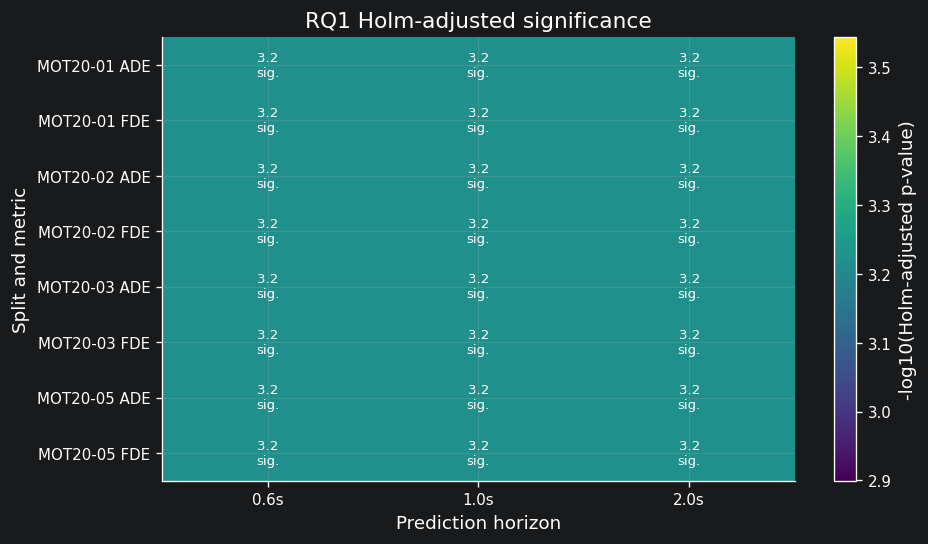

In [14]:
sig_df = split_level_df.copy()
sig_df["row_label"] = sig_df["split"] + " " + sig_df["metric_label"]
sig_df["neg_log10_holm_p"] = -np.log10(sig_df["holm_p_value"].clip(lower=1e-300))
sig_heatmap = sig_df.pivot_table(
    index="row_label", columns="horizon_label", values="neg_log10_holm_p", aggfunc="mean"
).reindex(index=row_order, columns=horizon_labels)
sig_flags = sig_df.pivot_table(
    index="row_label", columns="horizon_label", values="significant_adjusted", aggfunc="max"
).reindex(index=row_order, columns=horizon_labels)
sig_values = sig_heatmap.to_numpy(dtype=float)
threshold = -math.log10(0.05)

fig, ax = plt.subplots(figsize=(8.5, max(4.8, 0.42 * len(row_order))))
im = ax.imshow(sig_values, cmap="viridis", aspect="auto")
ax.set(title="RQ1 Holm-adjusted significance", xlabel="Prediction horizon", ylabel="Split and metric")
ax.set_xticks(np.arange(len(horizon_labels)), horizon_labels)
ax.set_yticks(np.arange(len(row_order)), row_order)

for row_idx in range(sig_values.shape[0]):
    for col_idx in range(sig_values.shape[1]):
        value = sig_values[row_idx, col_idx]
        is_sig = bool(sig_flags.iloc[row_idx, col_idx]) if pd.notna(sig_flags.iloc[row_idx, col_idx]) else False
        label = "" if np.isnan(value) else f"{value:.1f}\n{'sig.' if is_sig else 'n.s.'}"
        color = "white" if not np.isnan(value) and value > threshold else "black"
        ax.text(col_idx, row_idx, label, ha="center", va="center", color=color, fontsize=8)

fig.colorbar(im, ax=ax).set_label("-log10(Holm-adjusted p-value)")
save_figure(fig, figures_dir, base_dir, "rq1_holm_significance")
plt.show()


## Runtime comparison

Saved figures/rq1_latency_comparison.png


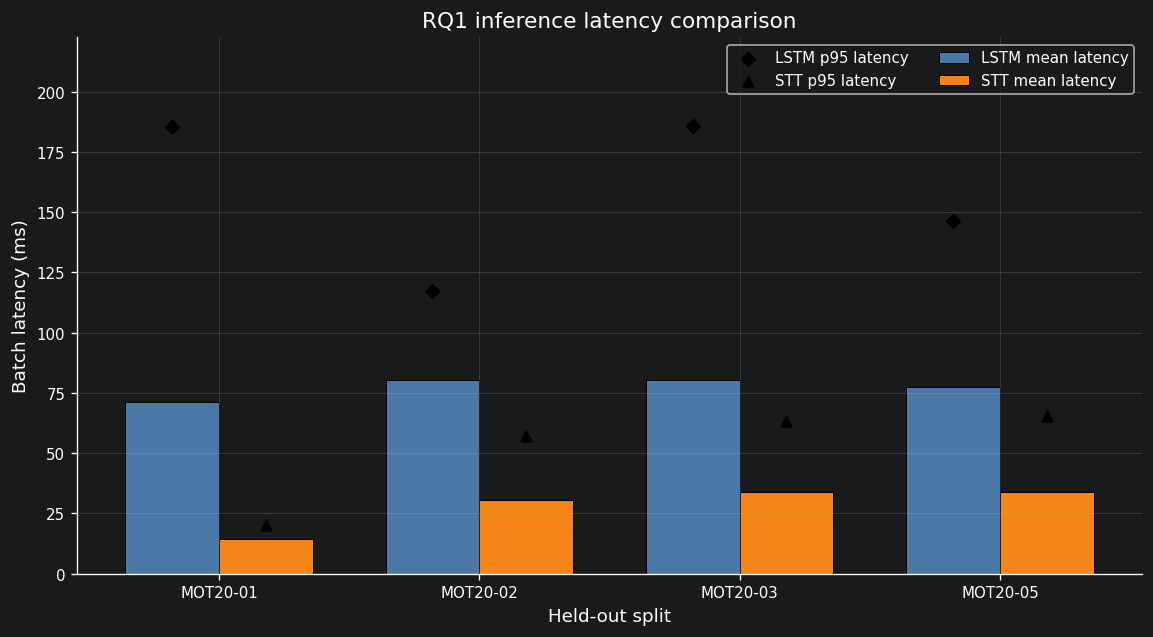

,split,baseline_mean_batch_latency_ms,treatment_mean_batch_latency_ms,baseline_p95_batch_latency_ms,treatment_p95_batch_latency_ms,baseline_budget_pass,treatment_budget_pass
0,MOT20-01,71.224262,14.343692,185.090405,20.164570,True,True
1,MOT20-02,80.516173,30.725951,117.325241,57.171811,False,True
2,MOT20-03,80.222163,33.692735,185.518065,63.198877,False,False
3,MOT20-05,77.489330,34.039618,146.218244,65.438920,False,False


In [15]:
latency_columns = [
    "baseline_mean_batch_latency_ms", "treatment_mean_batch_latency_ms",
    "baseline_p95_batch_latency_ms", "treatment_p95_batch_latency_ms",
    "baseline_budget_pass", "treatment_budget_pass",
]
require_columns(split_level_df, latency_columns, "RQ1 latency plot")
latency_df = split_level_df.groupby("split", as_index=False).agg(
    baseline_mean_batch_latency_ms=("baseline_mean_batch_latency_ms", "mean"),
    treatment_mean_batch_latency_ms=("treatment_mean_batch_latency_ms", "mean"),
    baseline_p95_batch_latency_ms=("baseline_p95_batch_latency_ms", "mean"),
    treatment_p95_batch_latency_ms=("treatment_p95_batch_latency_ms", "mean"),
    baseline_budget_pass=("baseline_budget_pass", lambda values: bool(values.dropna().all()) if values.notna().any() else pd.NA),
    treatment_budget_pass=("treatment_budget_pass", lambda values: bool(values.dropna().all()) if values.notna().any() else pd.NA),
).sort_values("split", key=lambda s: s.map(split_sort_key))

x = np.arange(len(latency_df))
width = 0.36
fig, ax = plt.subplots(figsize=(9.5, 5.2), constrained_layout=True)
ax.bar(x - width / 2, latency_df["baseline_mean_batch_latency_ms"], width, label="LSTM mean latency", color=MODEL_COLORS["LSTM"], edgecolor="black", linewidth=0.6)
ax.bar(x + width / 2, latency_df["treatment_mean_batch_latency_ms"], width, label="STT mean latency", color=MODEL_COLORS["STT"], edgecolor="black", linewidth=0.6)
ax.scatter(x - width / 2, latency_df["baseline_p95_batch_latency_ms"], marker="D", color="black", s=35, label="LSTM p95 latency", zorder=3)
ax.scatter(x + width / 2, latency_df["treatment_p95_batch_latency_ms"], marker="^", color="black", s=42, label="STT p95 latency", zorder=3)

budget_line = budget_line_from_summary(summary_df)
if budget_line is not None:
    ax.axhline(budget_line, color="crimson", linestyle="--", linewidth=1.5, label=f"Budget ({budget_line:g} ms)")

ax.set(title="RQ1 inference latency comparison", xlabel="Held-out split", ylabel="Batch latency (ms)")
ax.set_xticks(x, latency_df["split"])
ax.legend(ncols=2)
ax.set_ylim(0, latency_df[["baseline_p95_batch_latency_ms", "treatment_p95_batch_latency_ms"]].max().max() * 1.2)
save_figure(fig, figures_dir, base_dir, "rq1_latency_comparison")
plt.show()
display(latency_df)


## Pooled improvement summary

Saved figures/rq1_summary_improvement.png


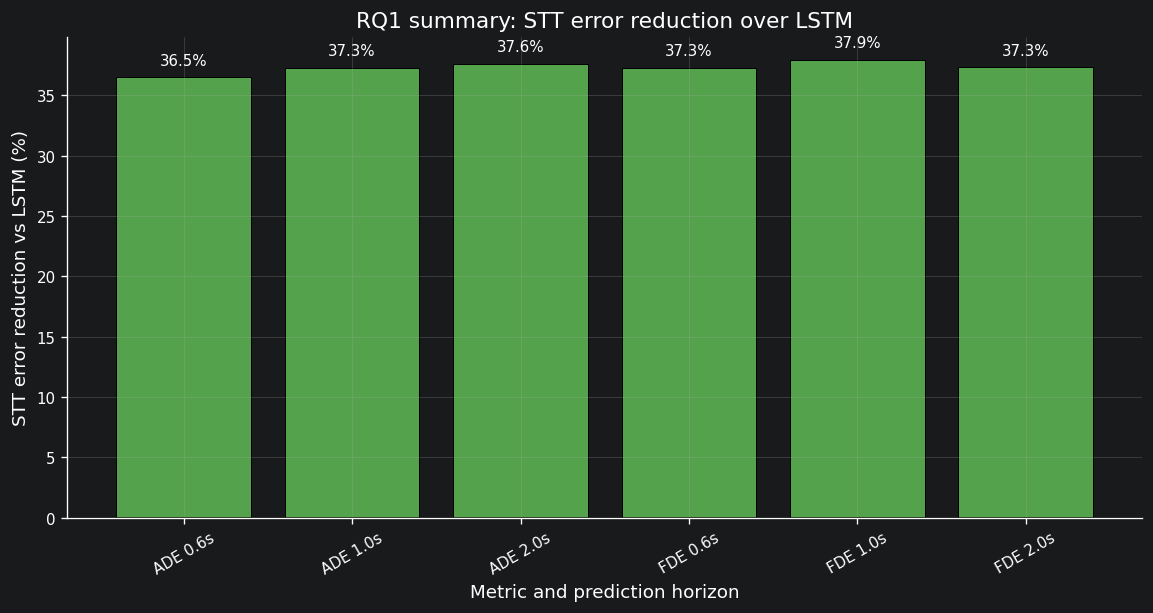

In [16]:
summary_source = pooled_df if not pooled_df.empty else split_level_df
summary_plot = summary_source.copy()
if pooled_df.empty:
    summary_plot = summary_plot.groupby(["metric_label", "horizon_for_plot", "horizon_label"], as_index=False).agg(
        improvement_pct=("improvement_pct", "mean"),
        significant_adjusted=("significant_adjusted", "max"),
        holm_p_value=("holm_p_value", "mean"),
    )
summary_plot["combo_label"] = summary_plot["metric_label"] + " " + summary_plot["horizon_label"]
summary_plot["metric_rank"] = summary_plot["metric_label"].map({metric: idx for idx, metric in enumerate(metric_order)})
summary_plot = summary_plot.sort_values(["metric_rank", "horizon_for_plot"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 5.0), constrained_layout=True)
colors = np.where(summary_plot["significant_adjusted"].fillna(False).astype(bool), "#54A24B", "#B9B9B9")
ax.bar(summary_plot["combo_label"], summary_plot["improvement_pct"], color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=1)
for idx, row in summary_plot.iterrows():
    ax.text(idx, row["improvement_pct"] + 0.8, f"{row['improvement_pct']:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set(title="RQ1 summary: STT error reduction over LSTM", xlabel="Metric and prediction horizon", ylabel="STT error reduction vs LSTM (%)")
ax.tick_params(axis="x", rotation=30)
save_figure(fig, figures_dir, base_dir, "rq1_summary_improvement")
plt.show()
